# Lab4 - ML Models (Classification) & Parameter Tuning and Validation 
Decision Trees, Ensemble Methods

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,precision_score, recall_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier


## Load Dataset

In [2]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")


print(df.shape)
df.head()

(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Exploratory Data Analysis (EDA)

### Dataset info

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

### Summary statistics

In [4]:
df.describe()


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


### Check class distribution

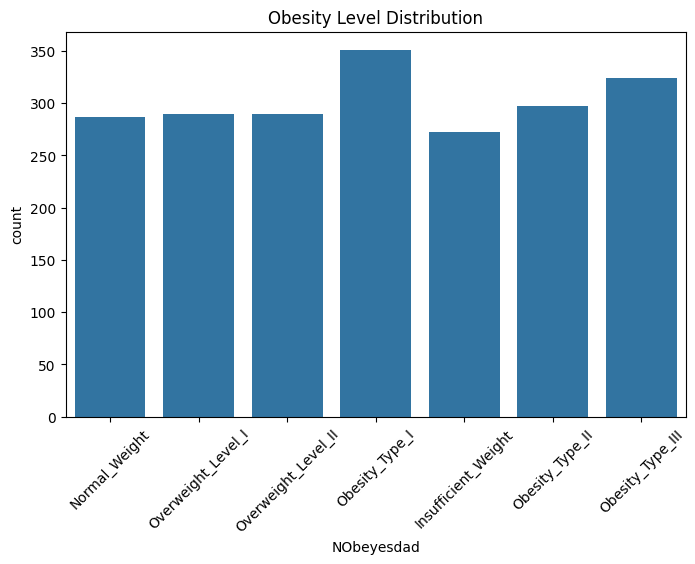

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation=45)
plt.title("Obesity Level Distribution")
plt.show()


### Correlation heatmap (numeric features)

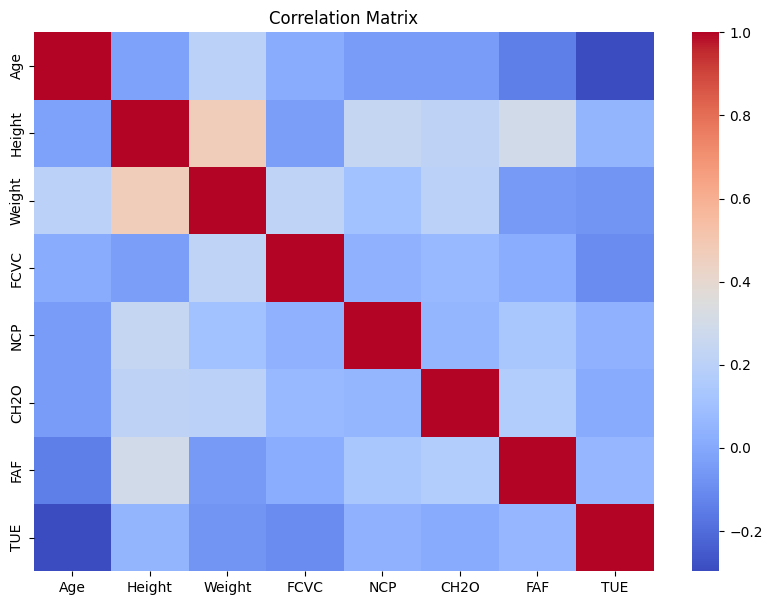

In [6]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


## Data Cleaning

### Check missing values

In [7]:
print(df.isnull().sum())


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


## Remove duplicates

In [8]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 24


## Encode Categorical Variables

In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


## Feature / Target Split

In [10]:
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Feature Scaling

In [11]:
scaler = StandardScaler()
# Fit scaler ONLY on training data
X_train_scaled =scaler.fit_transform(X_train)

# Transform test data
X_test_scaled =scaler.transform(X_test)


In [12]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8157894736842105


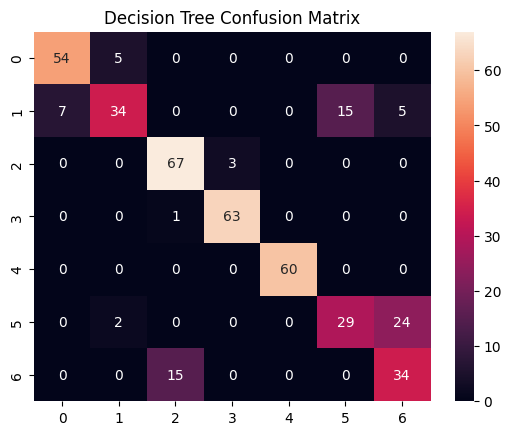

In [13]:
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()


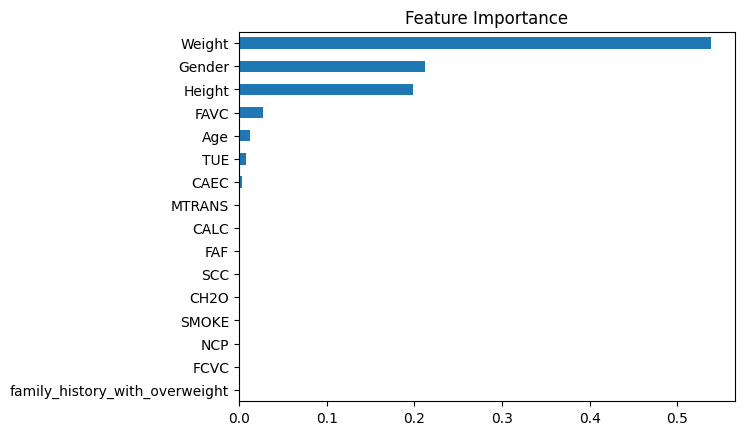

Gender                            0.211714
Age                               0.012540
Height                            0.198841
Weight                            0.538847
family_history_with_overweight    0.000000
FAVC                              0.027303
FCVC                              0.000000
NCP                               0.000000
CAEC                              0.003260
SMOKE                             0.000000
CH2O                              0.000000
SCC                               0.000000
FAF                               0.000000
TUE                               0.007495
CALC                              0.000000
MTRANS                            0.000000
dtype: float64

In [14]:
importance = dt.feature_importances_
features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

pd.Series(importance, index=features).sort_values(ascending=False)
features

In [15]:
X = df.drop(["NObeyesdad","CAEC","SMOKE","CH2O","SCC","FAF","TUE","CALC","MTRANS"], axis=1)
y = df["NObeyesdad"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
# Fit scaler ONLY on training data
X_train_scaled =scaler.fit_transform(X_train)

# Transform test data
X_test_scaled =scaler.transform(X_test)


dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8229665071770335


# Macro vs Micro Average in Classification

Used to combine metrics (like Precision, Recall, or F1-score) across classes.

---

## 1. Macro Average

- Treats **all classes equally**, regardless of their sample size.
- Formula (example for Precision):

$$
\text{Macro Precision} = \frac{1}{C}\sum_{i=1}^{C} Precision_i
$$

**Example:**

| Class | Precision |
|-------|-----------|
| A     | 0.90      |
| B     | 0.50      |
| C     | 0.40      |

**Macro Precision** = (0.90 + 0.50 + 0.40)/3 = **0.60**

> Note: All classes contribute equally, so rare classes have the same weight as frequent classes.

---

## 2. Micro Average

- Treats **every prediction equally**.
- Formula (example for Precision):

$$
\text{Micro Precision} = \frac{\sum TP}{\sum TP + \sum FP}
$$

**Example with counts:**

| Class | TP | FP | FN |
|-------|----|----|----|
| A     | 90 | 10 | 5  |
| B     | 20 | 30 | 10 |
| C     | 15 | 25 | 20 |

- Micro Precision = (90 + 20 + 15) / (90+20+15 + 10+30+25)  
= 125 / 190 ≈ **0.66**

> Note: Classes with more samples influence the metric more.

---

## 3. Summary Table

| Feature                  | Macro Average | Micro Average |
|---------------------------|---------------|---------------|
| Class weighting           | Equal         | By sample size |
| Sensitive to class imbalance | Yes         | Less          |
| Focus                     | Individual class performance | Overall prediction performance |

---

**Tips:**  
- We use **macro** when all classes matter equally (good for imbalanced datasets).  
- We use **micro** when we care about overall system performance.

In [16]:
# Micro F1
micro_f1 = f1_score(y_test, y_pred_dt, average='micro')
# Macro F1
macro_f1 = f1_score(y_test, y_pred_dt, average='macro')

print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)
# Precision
precision_micro = precision_score(y_test, y_pred_dt, average='micro')
precision_macro = precision_score(y_test, y_pred_dt, average='macro')

# Recall
recall_micro = recall_score(y_test, y_pred_dt, average='micro')
recall_macro = recall_score(y_test, y_pred_dt, average='macro')

print("Precision (micro):", precision_micro)
print("Precision (macro):", precision_macro)

print("Recall (micro):", recall_micro)
print("Recall (macro):", recall_macro)
# Full report
print(classification_report(y_test, y_pred_dt))


Micro F1: 0.8229665071770335
Macro F1: 0.8064192565720468
Precision (micro): 0.8229665071770335
Precision (macro): 0.819762029612483
Recall (micro): 0.8229665071770335
Recall (macro): 0.81162510184824
              precision    recall  f1-score   support

           0       0.88      0.95      0.91        59
           1       0.87      0.54      0.67        61
           2       0.81      0.99      0.89        70
           3       0.98      0.98      0.98        64
           4       1.00      1.00      1.00        60
           5       0.66      0.53      0.59        55
           6       0.54      0.69      0.61        49

    accuracy                           0.82       418
   macro avg       0.82      0.81      0.81       418
weighted avg       0.83      0.82      0.82       418



# Hyperparameters in Machine Learning

## What are Hyperparameters?

**Definition:** Hyperparameters are a high-level settings that control how a model learns. They are **set before training begins** and are **not learned from the data**.

**Key Distinction:**
| Aspect | Hyperparameters | Model Parameters |
|--------|----------------|------------------|
| **When set** | Before training | During training |
| **Examples** | Learning rate, max depth | Weights, coefficients |
| **How found** | Manual tuning, Grid Search | Optimization algorithm |

**Analogy:** Hyperparameters are like the settings on an oven—temperature and timer are set before you start baking. The recipe (model parameters) adjusts based on those settings. Or like the dials on an old-school radio—just as you tune a station for clarity.

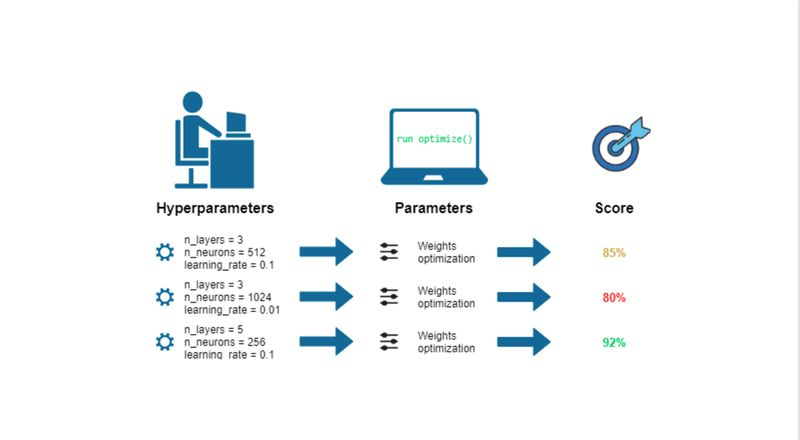

---
Consider Linear Regression, Linear regression aims to find a line that best represents the relationship between input features and the target variable, helping the model predict outcomes for new data based on this relationship.
$$ 
y=w*x+b
$$


Hyperparameters can:
1. Improve the accuracy of the model.
2. Better Generalization as they play a crucial role in how well a model adapts to new data 
3. Improve Training Efficiency (impacting both resource usage and training speed) as adjusting the learning rate in gradient-based algorithms,affects the speed.and how robust it remains in real-world applications.

                   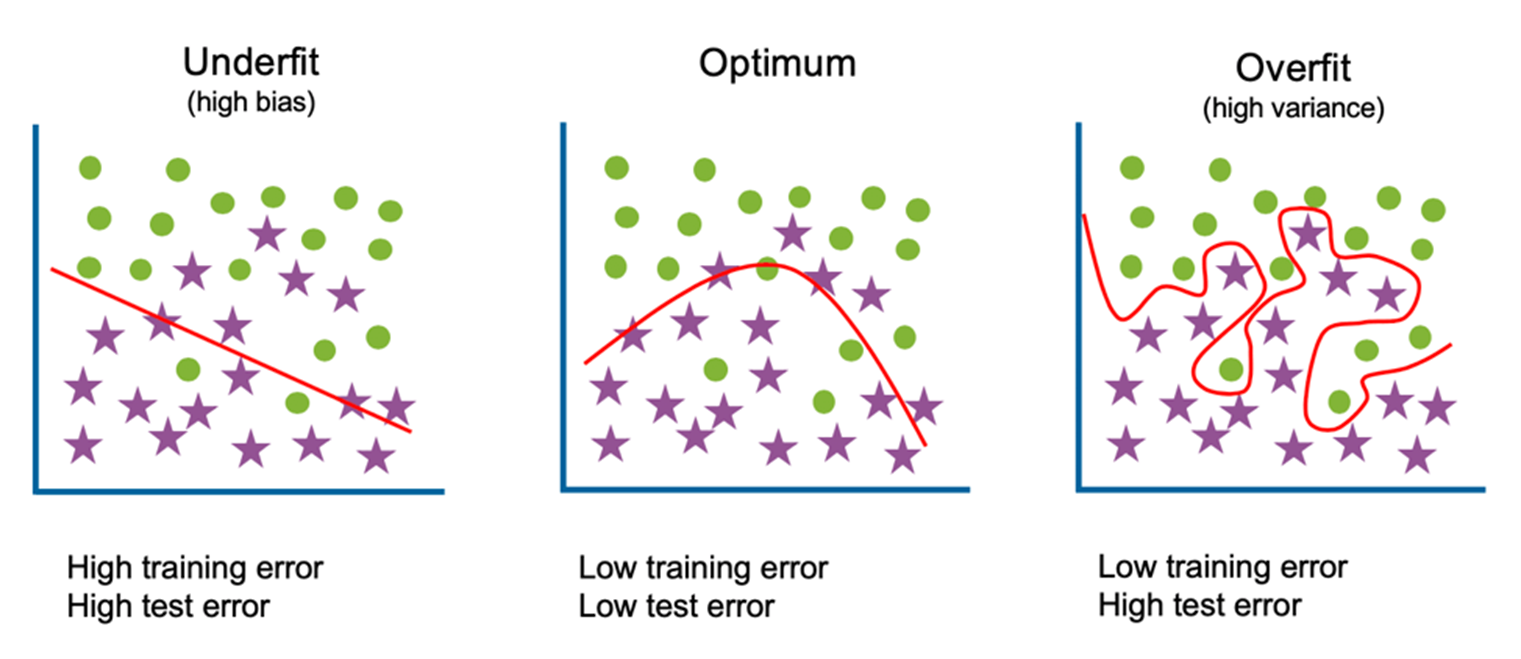

## 1. Logistic Regression

**Definition:** A linear classification algorithm that uses the sigmoid function to predict probabilities between 0 and 1.

### Key Hyperparameters


$$
z = w^T x + b
$$

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

$$
\hat{y} = \sigma(z)
$$
loss function

$$
L = - \left[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \right]
$$

$$
L_{reg} = L + \lambda ||w||^2
$$

Where:

- $x_i$ = feature vector  
- $y_i$ = label  
- $w$ = weight vector  
- $b$ = bias  
- $\lambda$ = regularization strength


#### `C` — Regularization Strength
- **Definition:** The inverse of regularization strength. Controls how much the model is penalized for complexity.
- **Type:** Positive float (default: 1.0)

| Value | Effect | Risk |
|-------|--------|------|
| Small (e.g., 0.01) | Strong regularization, simpler model | Underfitting |
| Large (e.g., 100) | Weak regularization, complex model | Overfitting |

**Example:**  
If the model memorizes training data but fails on new data (overfitting), **decrease C** to add regularization and simplify the model.

---

#### `penalty` — Regularization Type
- **Definition:** Specifies the norm used in the penalization.
- **Options:**
  - **`l1` (Lasso):** Can shrink some coefficients to exactly zero, performing feature selection.
  - **`l2` (Ridge):** Default. Shrinks coefficients but rarely to zero; handles correlated features well.
  - **`elasticnet`:** Combines L1 and L2 penalties.

**Example:**  
Use `penalty='l1'` when you have 1,000 features but suspect only 50 are actually important. The model will automatically ignore irrelevant features.

---

#### `solver` — Optimization Algorithm
- **Definition:** Algorithm to use in the optimization problem.
- **Common options:** `liblinear`, `lbfgs`, `sag`, `saga`

**Example:**  
For small datasets, `liblinear` works well. For large datasets with many samples, use `sag` or `saga` for faster convergence.

---

## 2. Decision Tree

**Definition:** A tree-structured classifier that splits data based on feature values, creating a flowchart of decisions leading to predictions.

### Key Hyperparameters

#### `max_depth` — Maximum Tree Depth
- **Definition:** The maximum number of levels in the tree. Limits how many splits can be made.
- **Type:** Integer or None (default: None)

| Depth | Characteristic | Result |
|-------|---------------|--------|
| 1 | Single split (stump) | High bias, underfitting |
| 5-10 | Moderate complexity | Often optimal |
| 50+ | Very deep, many rules | High variance, overfitting |

**Example:**  
A `max_depth=2` tree for loan approval might only check "Income &gt; $50k?" and "Credit Score &gt; 700?". A `max_depth=20` tree might create overly specific rules like "Reject if applicant is 34 years old, lives in zip 90210, and applied on Tuesday"—memorizing noise.

---

#### `min_samples_split` — Minimum Samples to Split
- **Definition:** The minimum number of samples required to split an internal node.
- **Type:** Integer or float (default: 2)

**Example:**  
Setting `min_samples_split=20` means a node must contain at least 20 data points before it can split further. This prevents the tree from creating branches for tiny groups of outliers.

---

#### `min_samples_leaf` — Minimum Samples in Leaf
- **Definition:** The minimum number of samples required to be at a leaf node.
- **Type:** Integer or float (default: 1)

**Example:**  
With `min_samples_leaf=5`, every final decision must be based on at least 5 training examples. This smooths the model and reduces sensitivity to noise.

---

#### `criterion` — Split Quality Measure
- **Definition:** Function to measure the quality of a split.
- **Options:**
  - **`gini`:** Measures impurity (default). Faster to compute.
  - **`entropy`:** Measures information gain. More computationally intensive.

**Example:**  
Both usually yield similar results. Use `gini` for speed.

---

## 3. K-Nearest Neighbors (KNN)

**Definition:** An instance-based learning algorithm that classifies new data points based on the majority class of their K closest neighbors in the training set.

### Key Hyperparameters
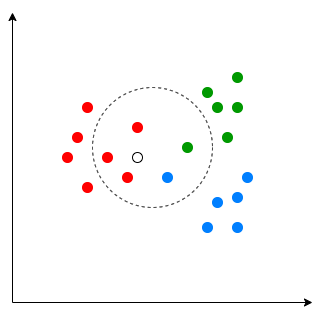
#### `n_neighbors` (K) — Number of Neighbors
- **Definition:** The number of nearest neighbors to consider when making a prediction.
- **Type:** Integer (default: 5)

| K Value | Behavior | Risk |
|---------|----------|------|
| 1 | Only nearest neighbor decides | Very sensitive to noise, overfitting |
| 3-5 | Small neighborhood | Captures local patterns |
| 50+ | Large neighborhood | Smooths too much, misses local patterns, underfitting |

**Example:**  
In a medical diagnosis system:
- **K=1:** Patient classified based on single most similar case—dangerous if that case was an anomaly.
- **K=15:** Classification considers 15 similar patients—more robust to individual outliers.

---

#### `weights` — Weight Function
- **Definition:** How to weight the contribution of neighbors.
- **Options:**
  - **`uniform`:** All neighbors have equal vote (default).
  - **`distance`:** Closer neighbors have greater influence (weighted by inverse of distance).

**Example:**  
In a real estate price predictor:
- **`uniform`:** 5 houses at 0.1 miles and 5 houses at 5 miles away have equal say in price.
- **`distance`:** The nearby houses dominate the prediction, which is usually more accurate.

---

#### `metric` — Distance Metric
- **Definition:** How to measure distance between data points.
- **Common options:** `minkowski`, `euclidean`, `manhattan`, `chebyshev`

**Example:**  
- **`euclidean` (p=2):** Straight-line distance. Good for continuous, geometric data.
- **`manhattan` (p=1):** Grid-based distance (sum of absolute differences). Better for high-dimensional data or grid-like city layouts.

---

## Summary Table

| Algorithm | Hyperparameter | Controls | Tuning Tip |
|-----------|---------------|----------|------------|
| **Logistic Regression** | `C` | Model complexity (inverse) | Decrease if overfitting |
| | `penalty` | Regularization type | Use `l1` for feature selection |
| **Decision Tree** | `max_depth` | Tree complexity | Limit to prevent overfitting |
| | `min_samples_split` | Splitting threshold | Increase to reduce sensitivity |
| | `min_samples_leaf` | Leaf size | Increase for smoother predictions |
| **KNN** | `n_neighbors` | Neighborhood size | Increase to reduce noise sensitivity |
| | `weights` | Voting scheme | Use `distance` for better local accuracy |
| | `metric` | Distance calculation | Match to data geometry |

---

## Key Takeaways

1. **Hyperparameters control model complexity** — they determine the bias-variance tradeoff.
2. **No universal best value** — optimal settings depend on your specific dataset.
3. **Use systematic search** — GridSearchCV or RandomizedSearchCV to find optimal combinations.
4. **Always validate** — Use cross-validation to ensure settings generalize to unseen data.

# Hyperparameter tuning methods
### Grid Search
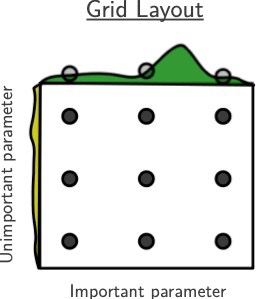

• Exhaustive search
• Thorough but expensive
• Specify grid for parameter search
• Can be run in parallel
• Can suffer from poor coverage
• Often run with multiple resolutions
( 0.0001 → poor
0.001  → decent
0.01   → best
0.1    → unstable)

#### How Grid Search Works?
1. Define a set of hyperparameter values to be tested (Parameter Grid Creation -Creates a Cartesian product of all hyperparameter values specified).
2. Train the model for each combination.
3. Evaluate the model using cross-validation.( Results (e.g., Accuracy, RMSE) for each combination are stored)
4. Select the combination that provides the best performance. (Then test on the test data)

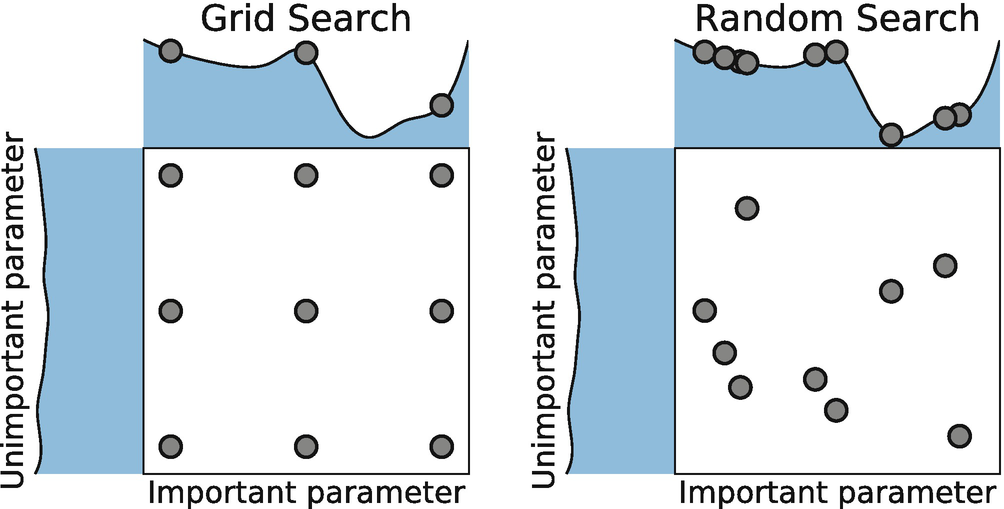


### Random Search
- Selects random combinations of hyperparameters from a given distribution
- Based on a Time Budget.
#### How It Works?
1. Define the hyperparameters: Specify the hyperparameters and their possible value ranges.
2. Randomly sample values: Instead of testing all possible combinations, it selects random sets of hyperparameters.
3. Train and evaluate: The model is trained and evaluated using cross-validation for each sampled combination.
4. Find the best: The best hyperparameter combination is chosen based on performance.

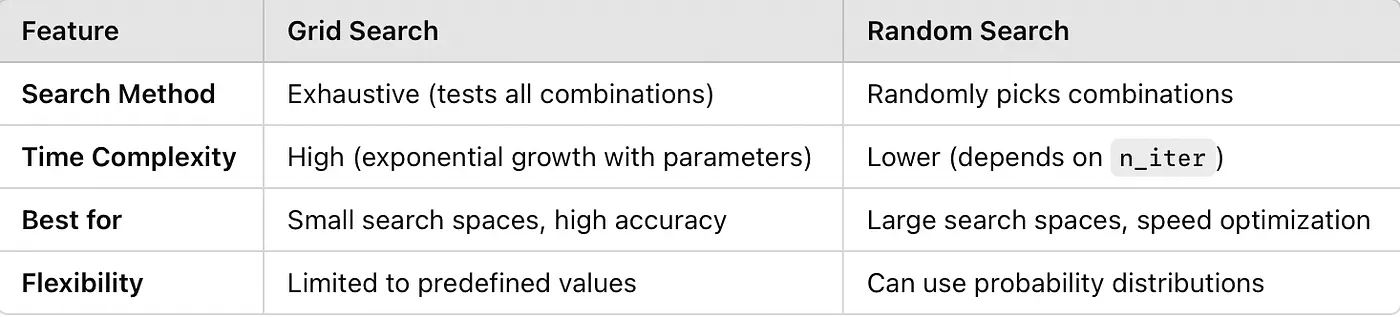

# Model Validation
## Hold Out Vaildation

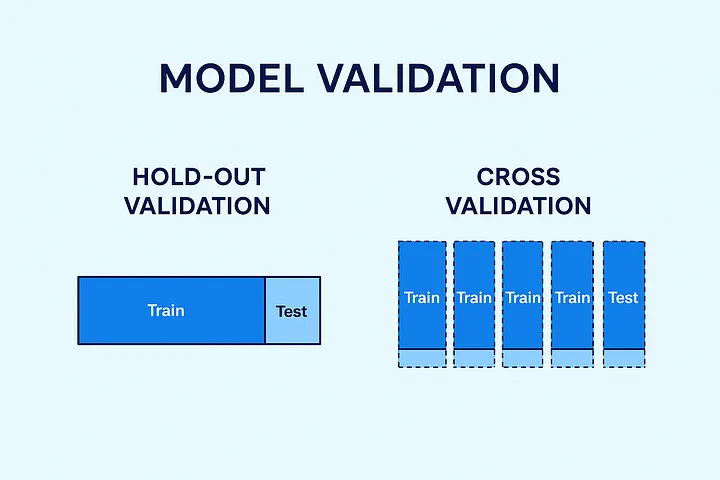



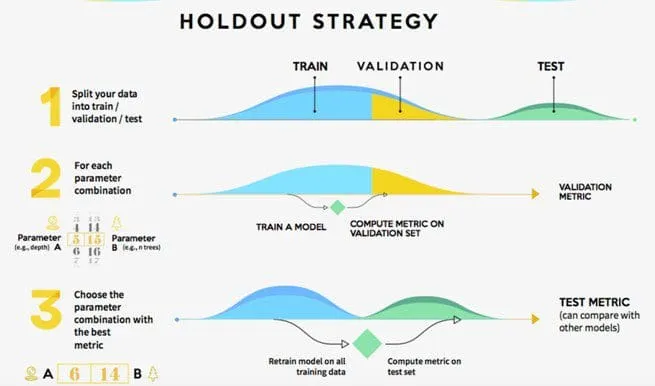


#### Aadvatages:

- Simple, fast, easy to understand

#### Disadvatages:

- The accuracy depends heavily on how the split was made.
- If the 20% test set is “unlucky” (not representative of the whole dataset), results can be misleading
---
## Cross Validation

A technique used to evaluate the performance of a machine learning model by training it on different subsets of the data and testing it on the remaining subset. 
- This is something different from the general train-test split
---
### LOOCV (Leave One Out Cross Validation)
The model is trained on the entire dataset except for one data point. This process is repeated for each data point in the dataset.

- All data points are used for training, resulting in low bias.
- Testing on a single data point can cause high variance, especially if the point is an outlier.
- It can be very time-consuming for large datasets as it requires one iteration per data point.
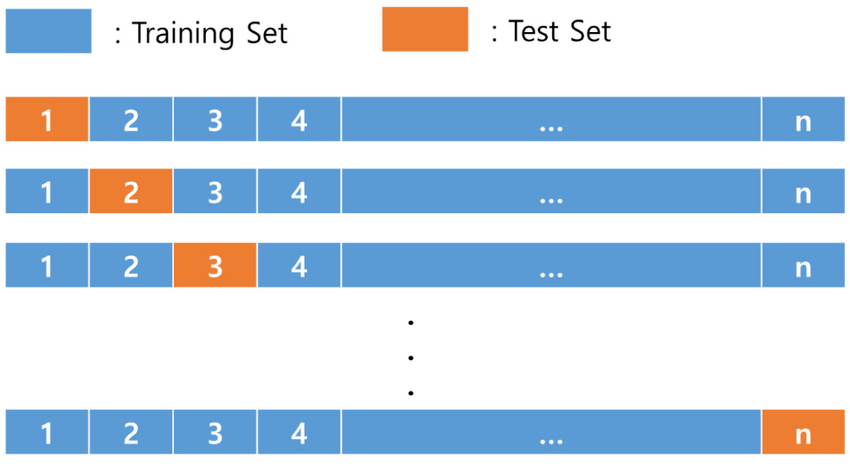

**Example:** One student studied 1 hour but scored 100 (an outlier).
---
## K-fold Cross Validation

- Known as rotation estimation or out-of-sample testing. 
- Splits the dataset into k equal-sized folds.
- The model is trained on k-1 folds and tested on the remaining fold.
- This process is repeated k times each time using a different fold for testing.

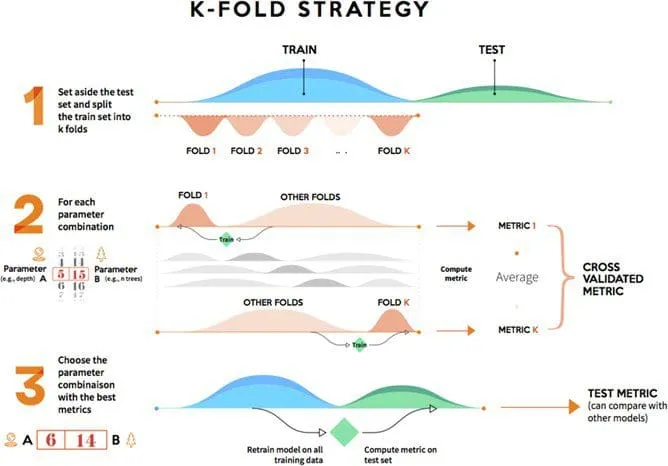


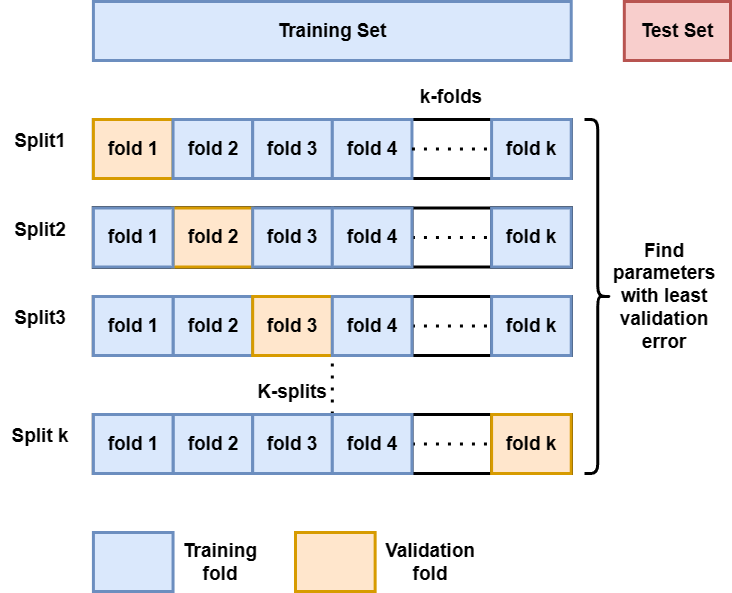


---
### Stratified Cross-Validation
- It ensures each fold of the cross-validation process has the same class distribution as the full dataset.
- This is useful for imbalanced datasets where some classes are underrepresented.
- 
**How it Works?**
  
- The samples are selected in the same proportion (by dividing the population into groups called ‘strata’ based on a characteristic) as they appear in the population.
- For example, if the population of interest has 30% male and 70% female subjects, then we divide the population into two (‘male’ and ‘female’) groups and choose 30% of the sample from the ‘male’ group and ‘70%’ of the sample from the ‘female’ group.


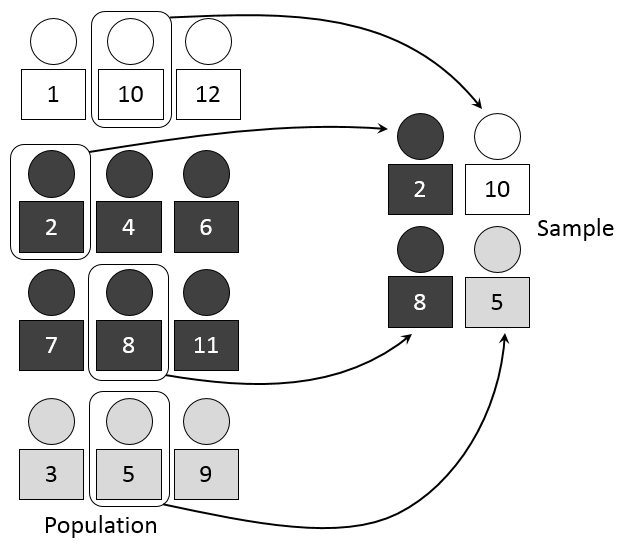

- The dataset is divided into k folds, keeping class proportions consistent in each fold.
- In each iteration, one fold is used for testing and the remaining folds for training.
- This process is repeated k times so that each fold is used once as the test set.
- It helps classification models generalize better by maintaining balanced class representation.
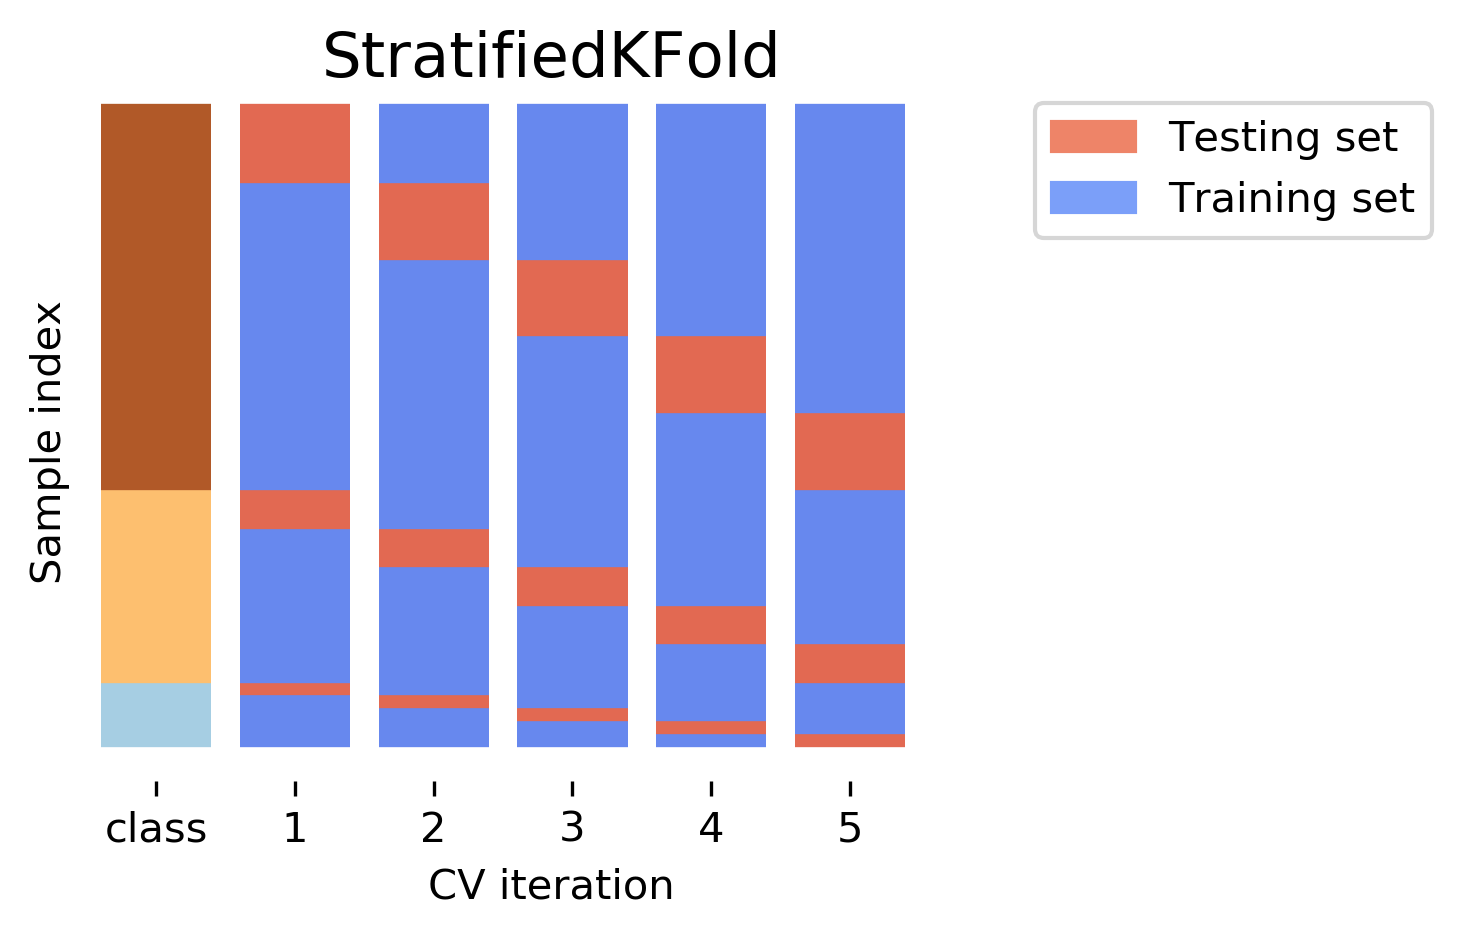

In [17]:
from sklearn.model_selection import KFold, cross_val_score, cross_validate

scores = cross_val_score(dt, X, y, cv=5)
print(scores.mean(), scores.std())

0.8256101339024475 0.0317343189724373


In [18]:
# Hold-Out Validation
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score, log_loss


X = df.drop(["NObeyesdad","CAEC","SMOKE","CH2O","SCC","FAF","TUE","CALC","MTRANS"], axis=1)
y = df["NObeyesdad"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid Search
grid = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
best_dt_grid = grid.best_estimator_



# Metrics function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average='macro'),
        "recall_macro": recall_score(y_test, y_pred, average='macro'),
        "f1_macro": f1_score(y_test, y_pred, average='macro'),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "roc_auc_macro": roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "cohen_kappa": cohen_kappa_score(y_test, y_pred),
        "log_loss": log_loss(y_test, y_prob)
    }
    return metrics

print("Hold-Out Grid Search Metrics:", evaluate_model(best_dt_grid, X_test, y_test))
print(best_dt_grid)
best_dt_grid

Hold-Out Grid Search Metrics: {'accuracy': 0.9593301435406698, 'precision_macro': 0.9592417168888676, 'recall_macro': 0.9580333848158583, 'f1_macro': 0.958074735490455, 'balanced_accuracy': 0.9580333848158583, 'roc_auc_macro': 0.981282590332216, 'mcc': 0.9526380271819678, 'cohen_kappa': 0.9524787170724857, 'log_loss': 1.1361808653569831}
DecisionTreeClassifier(min_samples_split=5, random_state=42)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [19]:
# Random Search
random = RandomizedSearchCV(dt, param_grid, n_iter=10, cv=5, scoring='accuracy', random_state=42)
random.fit(X_train, y_train)
best_dt_random = random.best_estimator_
print("Hold-Out Random Search Metrics:", evaluate_model(best_dt_random, X_test, y_test))
print(random.best_estimator_)
best_dt_random

Hold-Out Random Search Metrics: {'accuracy': 0.9617224880382775, 'precision_macro': 0.962604158647929, 'recall_macro': 0.9595085797445144, 'f1_macro': 0.9597114848646146, 'balanced_accuracy': 0.9595085797445144, 'roc_auc_macro': 0.9835653550362989, 'mcc': 0.9556433735695783, 'cohen_kappa': 0.9552660093909274, 'log_loss': 0.9713261932328531}
DecisionTreeClassifier(min_samples_leaf=2, random_state=42)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [20]:
# K-Fold Cross-Validation
from sklearn.model_selection import KFold, cross_val_score, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

# Use cross_validate to get multiple metrics
cv_results = cross_validate(dt, X, y, cv=kf, scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])
print("K-Fold CV Results:")
for metric in cv_results:
    print(metric, cv_results[metric].mean())
    

K-Fold CV Results:
fit_time 0.010371685028076172
score_time 0.013165092468261719
test_accuracy 0.9381960460339862
test_precision_macro 0.9362559736655538
test_recall_macro 0.9372960502019427
test_f1_macro 0.9361427714439172


In [21]:
grid_kf = GridSearchCV(dt, param_grid, cv=kf, scoring='accuracy')
grid_kf.fit(X, y)
print("Best params K-Fold Grid:", grid_kf.best_params_)

Best params K-Fold Grid: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [22]:
# Stratified K-Fold
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_skf = GridSearchCV(dt, param_grid, cv=skf, scoring='accuracy')
grid_skf.fit(X, y)
best_dt_skf = grid_skf.best_estimator_

print("Stratified K-Fold Metrics:", evaluate_model(best_dt_skf, X_test, y_test))

Stratified K-Fold Metrics: {'accuracy': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0, 'f1_macro': 1.0, 'balanced_accuracy': 1.0, 'roc_auc_macro': 1.0, 'mcc': 1.0, 'cohen_kappa': 1.0, 'log_loss': 2.220446049250313e-16}


In [23]:
import warnings
warnings.filterwarnings("ignore")

# Leave-One-Out Cross-Validation (LOOCV)
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
dt = DecisionTreeClassifier(random_state=42)

scores = cross_validate(dt, X, y, cv=loo, scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])
print("LOOCV Metrics (mean across folds):")
for metric in scores:
    print(metric, scores[metric].mean())

LOOCV Metrics (mean across folds):
fit_time 0.011934300501722438
score_time 0.014651982020006605
test_accuracy 0.9501677048394825
test_precision_macro 0.9501677048394825
test_recall_macro 0.9501677048394825
test_f1_macro 0.9501677048394825


# Ensemble Learning
- A technique that aggregates two or more learners (models) to produce better predictions **(increase accuracy)** than a single model alone.
- Base learner, Base model, and, in some cases, Base estimator -- divided into **strong learner** and **weak learners**
- Most Widley used in non Deep Learning Machine Model.
- Bias-variance 
A weak learner is a simple model that outperforms random guessing only marginally. A decision tree with a few levels, for example, can be employed as a weak learner.
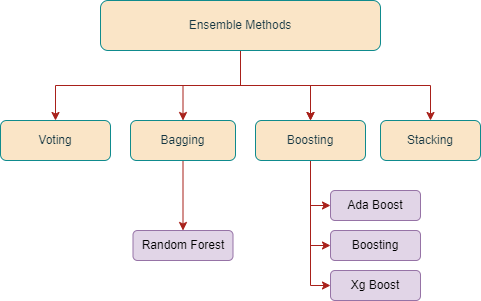

---

## Types of ensemble learning methods
Can be categorised:

-**Based on model composition**

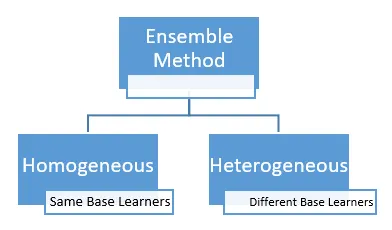

-**Based on the learning approach**

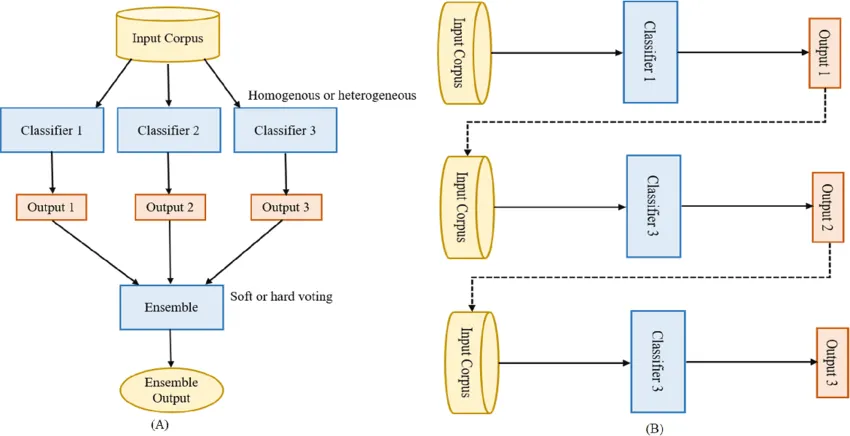

---
### Voting 

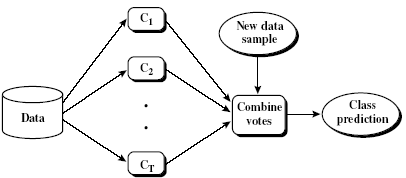


#### Majority voting (hard voting) and soft voting 
- Hard voting selects the class with the most individual model votes.
- While soft voting averages predicted probabilities for each class, selecting the highest average.
  
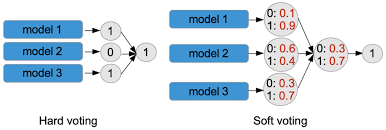
---
### Baagging (bootstrap aggregating)
- Bagging: averaging the prediction over a collection of classifiers.
- Instead of using the same training set to fit the individual classifiers in the ensemble, we
draw bootstrap samples **(random samples with replacement)** from the initial training set.

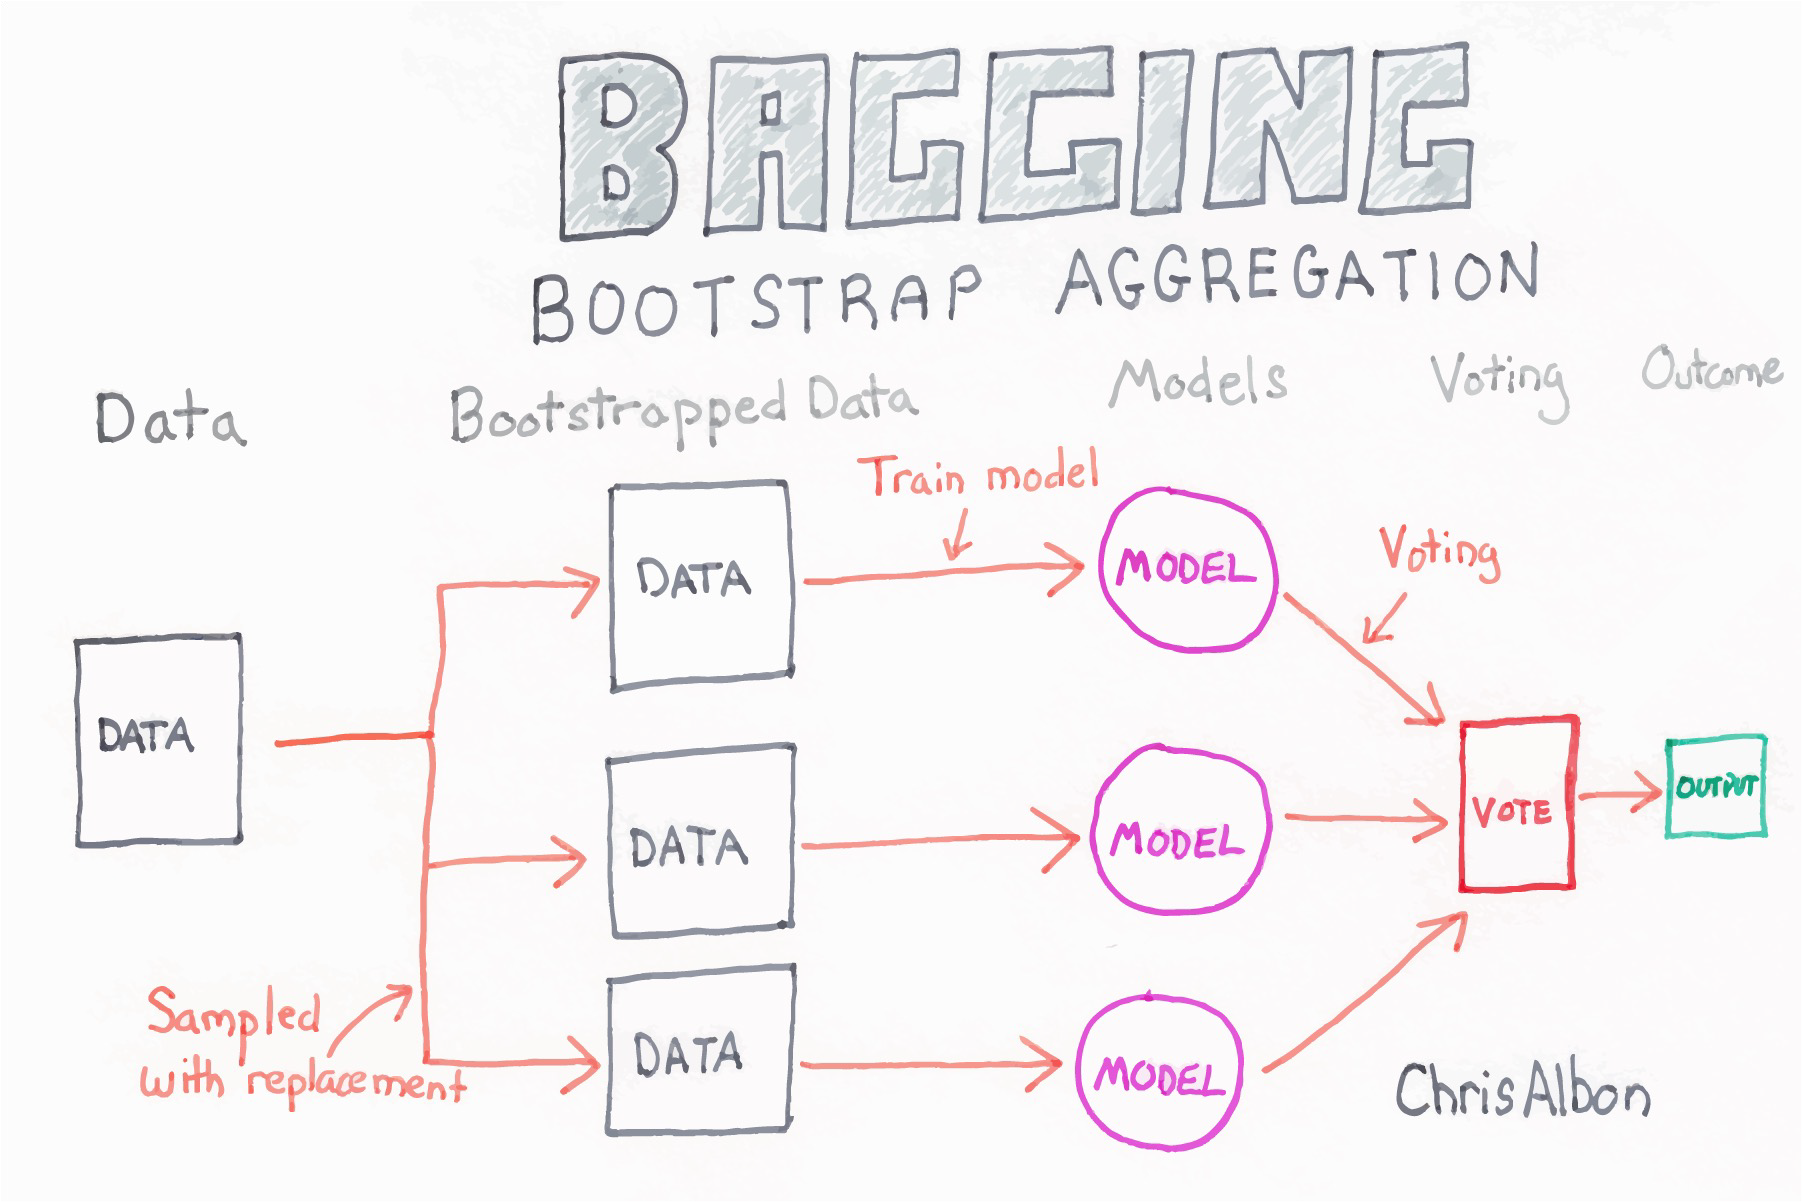

#### Randpm Forest
- Each classifier in the ensemble is a decision tree classifier and is generated using a random selection of attributes at each node to determine the split
– During classification, each tree votes and the most popular class is returned
■ Parameters:
– Number of trees in the forest
– The size of the random subsets of features to consider when splitting a node
– Other parameters : Number of nodes in each tree, maximum depth of the tree, etc
■ Two main methods to construct Random Forest:
– Forest RI ( random input selection ): Randomly select, at each node, F attributes as candidates for the split at the node.
– Forest RC ( random linear combinations ): Creates new attributes (or features) that are a linear combination of the existing attributes (reduces the correlation between individual classifiers)
■ Comparable in accuracy to Adaboost , but more robust to errors and outliers
■ Faster than bagging or boosting

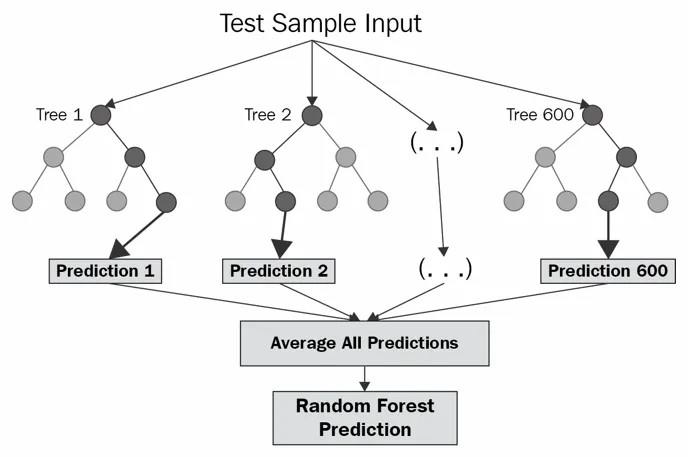


---
### Boosting

A sequential ensemble method that trains models one after another, with each new model focusing on the examples that previous models got wrong. It assigns higher weights to misclassified samples, forcing subsequent models to pay more attention to difficult cases.

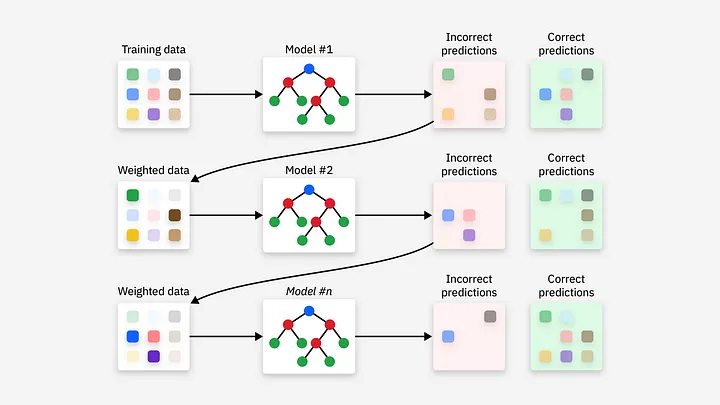

**Example:** AdaBoost(Adaptive Boosting), Gradient Boosting, XGBoost, LightGBM

The following are the steps in the boosting algorithm:

1. Initialise weights: At the start of the process, each training example is given equal weight.
2. Train a weak learner: The weighted training data is used to train a weak learner. 
3. Error calculation: The error of the weak learner on the training data is computed. The weighted sum of misclassified cases constitutes the error.
4. Update weights: Weights are updated according to the mistake rate of the training examples. Misclassified examples are given higher weights, whereas correctly classified examples are given lower weights.
5. Repeat: Steps 2–4 are repeated several times. 
6. Combine weak learners: The final model is made up of all of the weak learners that were trained in the preceding steps. The accuracy of each weak learner is weighted, and the final prediction is based on the weighted total of the weak learners.
7. Forecast: The finished model is used to forecast fresh instances’ class labels.
---
### Stacking (Stacked Generalization)
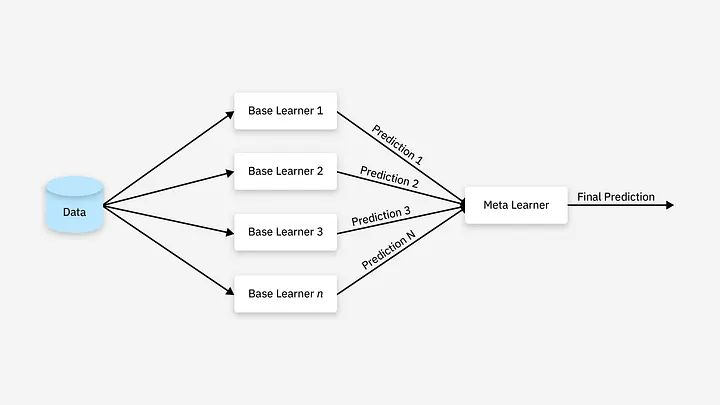

- Multiple models (called base models) are trained to solve the same task. 
* The predictions of these base models are combined with another model (called the meta-model) to make a final prediction

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_covtype
# Load dataset

data = fetch_covtype(as_frame=True)

df = data.frame
df




,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396.0,153.0,20.0,85.0,17.0,108.0,240.0,237.0,118.0,837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581008,2391.0,152.0,19.0,67.0,12.0,95.0,240.0,237.0,119.0,845.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581009,2386.0,159.0,17.0,60.0,7.0,90.0,236.0,241.0,130.0,854.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
581010,2384.0,170.0,15.0,60.0,5.0,90.0,230.0,245.0,143.0,864.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


In [25]:
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

    
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scaling (important for some models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Voting Classifier (Combining Different Models)

In [26]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


model1 = LogisticRegression(C=0.5,max_iter=1000) 
model2 = DecisionTreeClassifier(max_depth=4)
model3 = KNeighborsClassifier(n_neighbors=7)
# Train individual models
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

# Predictions
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

# Accuracy
acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)
acc3 = accuracy_score(y_test, pred3)

print("Logistic Regression Accuracy:", acc1)
print("Decision Tree Accuracy:", acc2)
print("KNN                   :", acc3)



Logistic Regression Accuracy: 0.7246886913418759
Decision Tree Accuracy: 0.7000593788456408
KNN                   : 0.9235131623107837


In [27]:
voting_clf = VotingClassifier(estimators=[('lr', model1),
                                          ('dt', model2),
                                          ('nb', model3)],voting='hard')
voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)

voting_acc = accuracy_score(y_test, y_pred)

print("Voting Accuracy:", voting_acc)

Voting Accuracy: 0.7774325964045679


In [28]:
voting_clf = VotingClassifier(estimators=[('lr', model1),
                                          ('dt', model2),
                                          ('nb', model3)],voting='soft')
voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)

voting_acc = accuracy_score(y_test, y_pred)

print("Voting Accuracy:", voting_acc)

Voting Accuracy: 0.8481364508661566


In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('dt', model2),
        ('nb', model3)
    ],
    voting='soft',
    weights=[1, 1, 2]  # Logistic gets more influence
)
voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)

voting_acc = accuracy_score(y_test, y_pred)

print("Voting Accuracy:", voting_acc)

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Logistic": pred1,
    "Tree": pred2,
    "KNN": pred3,
    "Voting": y_pred
})

print(comparison.head(20))

#### Bagging

In [31]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4),
    n_estimators=20,
    random_state=42
)

bagging_clf.fit(X_train, y_train)
y_pred = bagging_clf.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred))

Bagging Accuracy: 0.6969355352271456


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.6874177086650086


# Boosting

In [33]:
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    n_estimators=20,
    learning_rate=0.5,
    random_state=42
)

ada_clf.fit(X_train, y_train)
y_pred = ada_clf.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred))

# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(
    n_estimators=20,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train, y_train)
y_pred = gb_clf.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred))

AdaBoost Accuracy: 0.6701978434291713
Gradient Boosting Accuracy: 0.734326996721255


#### Stacking

In [34]:
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier

model1 = LogisticRegression(max_iter=1000)
model2 = DecisionTreeClassifier(max_depth=3)
model3 = KNeighborsClassifier(n_neighbors=7)

stack = StackingClassifier(
    estimators=[
        ('lr', model1),
        ('dt', model2),
        ('knn', model3)
    ],
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)
print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.9234959510511777


# Classification of Class Imbalanced Data Sets

- One class has far more samples than others.
- Causes models to favour the majority class and perform poorly on the minority class.
- Results in misleading accuracy.

Techniques to Handle Imbalanced Data
1. Use Better Evaluation Metrics
2. Resampling Techniques
    - Oversampling : Duplicates or generates minority class.
    - Under sampling : Removes majority class samples to balance the dataset.
4. Synthetic Minority Oversampling Technique (SMOTE)
5. Threshold Moving
6. Tree Based Models
7. Balanced Bagging Classifier

# Naive Bayse 

In [46]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------------
# 1. Create dataset
# -------------------------
data = pd.DataFrame({
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain'],
    'Temp': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes']
})
data


,Outlook,Temp,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [47]:

encoders = {}
for col in data.columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le


X = data.drop('PlayTennis', axis=1)
y = data['PlayTennis']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)


model = CategoricalNB()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)



Accuracy: 0.6666666666666666


In [48]:
test_sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temp': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

# Encode test sample using SAME encoders
for col in test_sample.columns:
    test_sample[col] = encoders[col].transform(test_sample[col])

# Predict
prediction = model.predict(test_sample)
result = encoders['PlayTennis'].inverse_transform(prediction)

print("Prediction:", result[0])

Prediction: No
